# Data Understanding & Data Preparation
**CRISP-DM Fase 1-2 — pembersihan & pra-pemrosesan sebelum modelling.**

Notebook ini menampilkan setiap langkah secara eksplisit (missing values, duplikat, rentang sensor, keseimbangan kelas, one-hot encoding, scaling, penanganan imbalance). Semua memakai fungsi yang sama dari paket `src/` yang dipakai model, jadi notebook ini **konsisten** dengan pipeline sebenarnya (tidak ada reimplementasi terpisah yang bisa menyimpang).

Prinsip kunci anti-bocor: scaling / imputasi / one-hot dilakukan **di dalam pipeline tiap fold CV**, bukan sekali di seluruh data. Di sini kita `fit_transform` di seluruh data hanya untuk *memperlihatkan* bentuk hasilnya.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src import config
from src.load_data import load_relabeled, class_balance, run_summary, missing_report
from src.preprocess import trim_warmup, encode_labels, build_xy, make_preprocessor, prepare

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

## 1. Muat & gabungkan data
14 file CSV hasil relabel digabung. Tiap file = 1 trial = 1 `run_id` (dipakai sebagai grup CV, **bukan** fitur). `elapsed` diparse ke `elapsed_sec`, `food_type` dinormalkan.

In [2]:
df = load_relabeled()
print("Shape gabungan:", df.shape)
print("Jumlah run (grup):", df[config.GROUP_COLUMN].nunique())
df.head()

Shape gabungan: (37310, 10)
Jumlah run (grup): 14


,elapsed,mq2,mq135,mq4,humidity,tempC,food_type,label,run_id,elapsed_sec
0,02:55:27,787,640,1088,94.6,26.4,Ayam Goreng,fresh,dataset_Ayam_Goreng_20260406_082148,10527
1,02:55:57,764,624,1066,98.0,26.8,Ayam Goreng,fresh,dataset_Ayam_Goreng_20260406_082148,10557
2,02:56:27,771,618,1055,98.3,26.8,Ayam Goreng,fresh,dataset_Ayam_Goreng_20260406_082148,10587
3,02:56:57,760,623,1052,98.6,26.8,Ayam Goreng,fresh,dataset_Ayam_Goreng_20260406_082148,10617
4,02:57:27,736,594,1035,98.9,26.8,Ayam Goreng,fresh,dataset_Ayam_Goreng_20260406_082148,10647


## 2. Inspeksi struktur
Tipe data tiap kolom dan ringkasan statistik.

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 37310 entries, 0 to 37309
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   elapsed      37310 non-null  str    
 1   mq2          37310 non-null  int64  
 2   mq135        37310 non-null  int64  
 3   mq4          37310 non-null  int64  
 4   humidity     37310 non-null  float64
 5   tempC        37310 non-null  float64
 6   food_type    37310 non-null  str    
 7   label        37310 non-null  str    
 8   run_id       37310 non-null  str    
 9   elapsed_sec  37310 non-null  int64  
dtypes: float64(2), int64(4), str(4)
memory usage: 2.8 MB


,mq2,mq135,mq4,humidity,tempC,elapsed_sec
count,37310.000000,37310.000000,37310.000000,37310.000000,37310.000000,37310.000000
mean,777.134039,629.263441,983.970276,97.992270,28.922919,46560.085151
std,188.818416,170.544049,183.343995,3.627372,1.112539,30973.045431
min,310.000000,197.000000,589.000000,66.500000,25.800000,27.000000
25%,693.000000,561.000000,865.000000,97.700000,28.300000,21867.000000
50%,816.000000,650.000000,975.000000,100.000000,28.900000,42087.000000
75%,892.750000,759.000000,1061.000000,100.000000,29.600000,64857.000000
max,1721.000000,1157.000000,2013.000000,100.000000,33.500000,129597.000000


## 3. Missing values
DHT22 (humidity/tempC) kadang mengembalikan NaN. Kita hitung. Pipeline tetap memasang `SimpleImputer(median)` sebagai jaring pengaman walau saat ini 0 NaN.

In [4]:
print("Missing per kolom fitur:")
print(missing_report(df).to_string())
print("\nTotal sel kosong di seluruh dataframe:", int(df.isna().sum().sum()))

Missing per kolom fitur:
mq2         0
mq135       0
mq4         0
humidity    0
tempC       0

Total sel kosong di seluruh dataframe: 0


## 4. Duplikat
Dua sudut pandang:
- **Baris duplikat utuh** (termasuk `run_id`): kandidat untuk dibuang.
- **Pembacaan sensor identik dalam run+label yang sama**: ini *wajar* untuk sensor lambat yang nilainya menahan (hold) beberapa detik — bukan error. Kita laporkan jumlahnya tapi tidak otomatis membuang, karena membuangnya akan mendistorsi distribusi waktu tiap run.

In [5]:
full_dupes = int(df.duplicated().sum())
sensor_cols = ["run_id", "mq2", "mq135", "mq4", "humidity", "tempC"]
reading_dupes = int(df.duplicated(subset=sensor_cols).sum())
print(f"Baris duplikat utuh: {full_dupes}")
print(f"Pembacaan sensor identik dalam run yang sama: {reading_dupes} "
      f"({reading_dupes/len(df):.1%}) -> dianggap stable-hold, TIDAK dibuang")

Baris duplikat utuh: 0
Pembacaan sensor identik dalam run yang sama: 515 (1.4%) -> dianggap stable-hold, TIDAK dibuang


## 5. Sanity rentang nilai sensor
Cek nilai mustahil: `humidity` harus 0-100%, sensor MQ (ADC) non-negatif, suhu wajar.

         mq2   mq135     mq4  humidity  tempC
min    310.0   197.0   589.0      66.5   25.8
max   1721.0  1157.0  2013.0     100.0   33.5
mean   777.1   629.3   984.0      98.0   28.9
std    188.8   170.5   183.3       3.6    1.1

humidity di luar 0-100: 0
nilai MQ negatif: 0


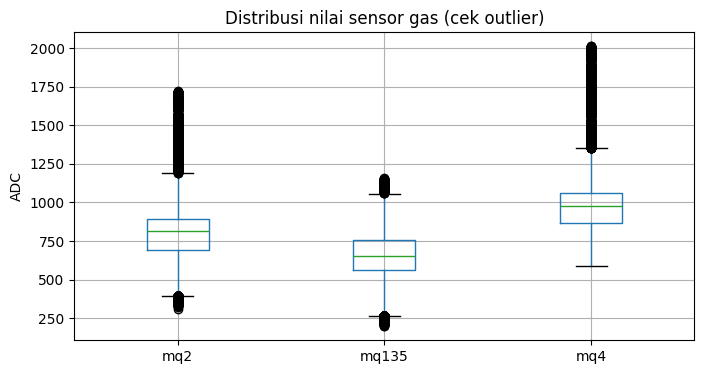

In [6]:
stats = df[["mq2", "mq135", "mq4", "humidity", "tempC"]].describe().loc[["min", "max", "mean", "std"]]
print(stats.round(1).to_string())
print("\nhumidity di luar 0-100:", int(((df.humidity < 0) | (df.humidity > 100)).sum()))
print("nilai MQ negatif:", int((df[["mq2", "mq135", "mq4"]] < 0).sum().sum()))

fig, ax = plt.subplots(figsize=(8, 4))
df[["mq2", "mq135", "mq4"]].boxplot(ax=ax)
ax.set_title("Distribusi nilai sensor gas (cek outlier)")
ax.set_ylabel("ADC")
plt.show()

## 6. Keseimbangan kelas (inti pertanyaan imbalance)
Secara keseluruhan imbalance-nya ringan, **tapi per makanan berat dan arahnya berbeda**: Ayam/Nasi mayoritas spoiled, Telur mayoritas fresh. Ini penting — bukan sekadar satu kelas minoritas global.

Keseluruhan:
label
spoiled    22081
fresh      15229
Name: count, dtype: int64
fraksi spoiled: 0.592

Per makanan:


label,fresh,spoiled,total
food_type,,,
Ayam Goreng,1487,7053,8540
Ikan Goreng,3428,5040,8468
Nasi Putih,1692,5668,7360
Telur Rebus,8622,4320,12942


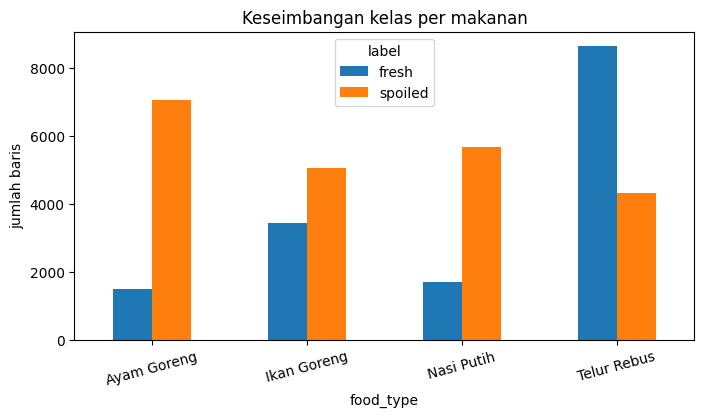

In [7]:
print("Keseluruhan:")
print(df["label"].value_counts())
print("fraksi spoiled:", round((df["label"] == "spoiled").mean(), 3))

bal = class_balance(df)
print("\nPer makanan:")
display(bal)

ax = bal[["fresh", "spoiled"]].plot.bar(figsize=(8, 4))
ax.set_title("Keseimbangan kelas per makanan")
ax.set_ylabel("jumlah baris")
ax.tick_params(axis="x", rotation=15)
plt.show()

### Strategi penanganan imbalance yang dipakai
1. **`class_weight='balanced'`** pada Logistic Regression, Decision Tree, Random Forest — menimbang kelas berbanding terbalik dengan frekuensinya saat training. (KNN tidak punya parameter ini; dikompensasi dengan opsi `weights='distance'`.)
2. **`StratifiedGroupKFold`** — menjaga proporsi fresh:spoiled tiap fold seimbang sambil tetap memisahkan run.
3. **Metrik berfokus kelas** — kita laporkan precision/recall/F1 per kelas dan memprioritaskan **recall `spoiled`**, bukan akurasi global.

**Kenapa bukan resampling (SMOTE / over/under-sampling)?** Untuk data sensor time-series berbasis run, menambah sampel sintetis yang mencampur antar-run berisiko bocor dan secara fisik meragukan. `class_weight` bebas-bocor, deterministik, dan mudah dipertanggungjawabkan di sidang. (Resampling tetap bisa ditambahkan di dalam pipeline per-fold bila ingin dibandingkan sebagai eksperimen lanjutan.)

## 7. Warm-up trim (penanganan data tidak stabil)
Beberapa menit pertama tiap run dibuang karena sensor masih panas/menstabilkan diri.

In [8]:
before = len(df)
df_trimmed = trim_warmup(df)
print(f"Sebelum trim: {before} baris")
print(f"Sesudah trim ({config.WARMUP_MINUTES} menit pertama/run dibuang): {len(df_trimmed)} baris")
print(f"Dibuang: {before - len(df_trimmed)} baris")

Sebelum trim: 37310 baris
Sesudah trim (2 menit pertama/run dibuang): 37304 baris
Dibuang: 6 baris


## 8. Encoding label target
`fresh` -> 0, `spoiled` -> 1 (kelas positif = spoiled, yang ingin dideteksi).

In [9]:
print("Mapping:", config.LABEL_MAP)
df_enc = encode_labels(df_trimmed)
print(df_enc["label"].value_counts().rename({0: "fresh(0)", 1: "spoiled(1)"}).to_string())

Mapping: {'fresh': 0, 'spoiled': 1}
label
spoiled(1)    22081
fresh(0)      15223


## 9. One-hot encoding + scaling (ColumnTransformer)
`food_type` di-one-hot, fitur numerik diimputasi (median) lalu di-`StandardScaler`. Di bawah kita `fit_transform` seluruh data **hanya untuk memperlihatkan bentuk hasilnya**; di modelling, transformer ini hidup di dalam pipeline dan di-fit ulang tiap fold.

In [10]:
X_demo, y_demo, groups_demo = build_xy(df_enc)
prep = make_preprocessor()
X_transformed = prep.fit_transform(X_demo)
feature_names = prep.get_feature_names_out()
print("Fitur masuk model (mq numerik + one-hot food_type):")
print(list(feature_names))
print("\nShape setelah transform:", X_transformed.shape)
pd.DataFrame(X_transformed, columns=feature_names).head()

Fitur masuk model (mq numerik + one-hot food_type):
['num__mq2', 'num__mq135', 'num__mq4', 'num__humidity', 'num__tempC', 'cat__food_type_Ayam Goreng', 'cat__food_type_Ikan Goreng', 'cat__food_type_Nasi Putih', 'cat__food_type_Telur Rebus']

Shape setelah transform: (37304, 9)


,num__mq2,num__mq135,num__mq4,num__humidity,num__tempC,cat__food_type_Ayam Goreng,cat__food_type_Ikan Goreng,cat__food_type_Nasi Putih,cat__food_type_Telur Rebus
0,0.052100,0.062707,0.567300,-0.935750,-2.267841,1.0,0.0,0.0,0.0
1,-0.069715,-0.031126,0.447307,0.001989,-1.908273,1.0,0.0,0.0,0.0
2,-0.032641,-0.066314,0.387310,0.084731,-1.908273,1.0,0.0,0.0,0.0
3,-0.090901,-0.036991,0.370947,0.167472,-1.908273,1.0,0.0,0.0,0.0
4,-0.218012,-0.207063,0.278225,0.250214,-1.908273,1.0,0.0,0.0,0.0


## 10. Dataset siap-model
`prepare()` merangkum langkah 7-9 (baseline-correction opsional, warm-up trim, label encode) dan mengembalikan `X`, `y`, `groups`. Inilah yang masuk ke `tune_models`.

In [11]:
X, y, groups = prepare(df)
print("X shape:", X.shape)
print("Kolom X (sebelum one-hot di pipeline):", list(X.columns))
print("Jumlah grup (run):", groups.nunique())
print("Fraksi positif (spoiled):", round(float(y.mean()), 3))
print("\nBaseline correction aktif?", config.BASELINE_CORRECTION)

X shape: (37304, 6)
Kolom X (sebelum one-hot di pipeline): ['mq2', 'mq135', 'mq4', 'humidity', 'tempC', 'food_type']
Jumlah grup (run): 14
Fraksi positif (spoiled): 0.592

Baseline correction aktif? False


## Ringkasan langkah & best practice
| Langkah | Status |
|---|---|
| Gabung 14 run + tag `run_id` | OK |
| Missing values (imputasi median di pipeline) | OK |
| Cek duplikat & rentang nilai | OK (dilaporkan) |
| Buang fitur bocor (`elapsed`, `run_id`) | OK |
| Warm-up trim | OK |
| Label encode (spoiled=1) | OK |
| One-hot `food_type` | OK |
| Scaling `StandardScaler` (di dalam fold CV) | OK |
| Imbalance: `class_weight='balanced'` + stratified CV + fokus recall | OK |
| Resampling (SMOTE) | Tidak dipakai (alasan di bagian 6) |

Pemodelan & evaluasi ada di `analisis_model.ipynb`.